# シグモイド関数まとめ（G検定対策）

- **作成者：** Megumi Kawakami
- **作成日：** 2026年4月23日
- **作成ツール：** [Claude Sonnet 4.6 (Anthropic)](https://claude.ai) との対話をもとに作成

---

> このノートブックはG検定対策として、シグモイド関数の定義・微分・勾配消失問題をまとめたものです。

- シグモイド関数の定義と実装
- 微分（sigmoid_prime）とバックプロパゲーションへの応用
- 勾配消失問題（Vanishing Gradient Problem）の解説
- 補足：合成関数の微分の詳細 

## 1. シグモイド関数

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- 出力が **0〜1** の範囲に収まる
- ニューラルネットワークの活性化関数として使われる

## 2. シグモイド関数の微分

$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

- 自分自身を使って微分が表現できるシンプルな形
- **バックプロパゲーション**の勾配計算に使われる

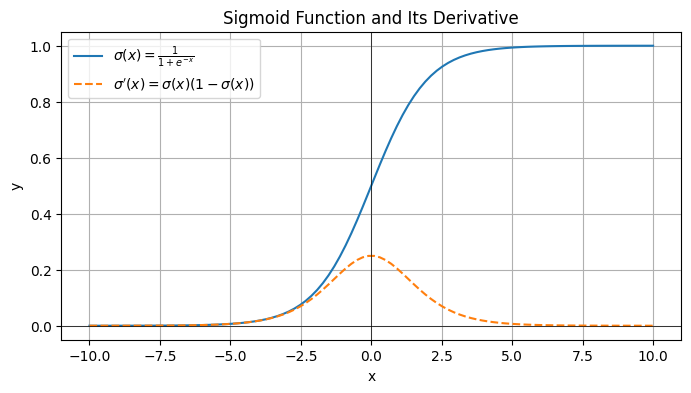

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x):
    return sigmoid(x) * (1 - sigmoid(x))

x = np.linspace(-10, 10, 100)

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid(x), label=r'$\sigma(x) = \frac{1}{1+e^{-x}}$')
plt.plot(x, sigmoid_prime(x), label=r"$\sigma'(x) = \sigma(x)(1-\sigma(x))$", linestyle='--')
plt.title(r'Sigmoid Function and Its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

## 3. 勾配消失問題（Vanishing Gradient Problem）

シグモイド関数の微分 $\sigma'(x)$ は、最大値が0.25にしかならないので、隠れ層を遡るごとに（活性化関数の微分が描け合わさって）伝播していく誤差はどんどん小さくなり勾配消失問題が発生する（公式テキスト）

$x$ が大きい（または小さい）とき、**ほぼ0に近づく**。

$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

| x の値 | $\sigma(x)$ | $\sigma'(x)$ |
|--------|------------|--------------|
| 0      | 0.5        | **0.25**（最大値） |
| 2      | 0.88       | 0.10 |
| 5      | 0.99       | **0.006**（ほぼ0） |
| -5     | 0.007      | **0.006**（ほぼ0） |

### なぜ問題なのか？
- バックプロパゲーションでは勾配を**掛け算**しながら伝播させる
- 層が深いほど、0に近い値を何度も掛けることになる
- 結果として**前の層ほど勾配がほぼ0になり、学習が止まる**

### 対策
- **ReLU関数** の使用（現在の主流）
- **Batch Normalization**
- **残差接続（ResNet）**

## 補足：合成関数の微分の詳細（置換を使った解説）

$1 + e^{-x} = A$ と置くと、

$$\sigma(x) = \frac{1}{A} = A^{-1}$$

### Step 1：それぞれの微分を求める

$$\frac{d\sigma}{dA} = -A^{-2} = -\frac{1}{A^2}$$

$$\frac{dA}{dx} = \frac{d}{dx}(1 + e^{-x}) = -e^{-x}$$

### Step 2：連鎖律（チェーンルール）を適用する

$$\sigma'(x) = \frac{d\sigma}{dx} = \frac{d\sigma}{dA} \cdot \frac{dA}{dx}$$

$$= -\frac{1}{A^2} \cdot (-e^{-x})$$

$$= \frac{e^{-x}}{A^2}$$

### Step 3：A を元に戻す

$$= \frac{e^{-x}}{(1 + e^{-x})^2}$$


### Step 4:ここで、分子と分母を整理する。

$$= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}}$$

$$= \frac{1}{1 + e^{-x}} \cdot \frac{(1 + e^{-x}) - 1}{1 + e^{-x}}$$  ＊ここで　分子に1を足して引くのがみそ😊

$$= \frac{1}{1 + e^{-x}} \cdot \left(1 - \frac{1}{1 + e^{-x}}\right)$$

$$= \sigma(x)(1 - \sigma(x))$$
